# Method 34 - Polar stereographic projection, 99th percentile 1980-2000 and 93.5th percentile 2000-2023 random sampling overflow bins and month distribution average cap

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, plot_heatmap_npts_xy, plot_3d, cross_sec_lon, cross_sec_lon_prob

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]


# Calculate density based on temperature, salinity, latitude and depth
df_ST['Pressure_[dbar]'] = gsw.p_from_z(-df_ST['Depth_[m]'].values, df_ST['Latitude_[deg_N]'].values)
df_ST['Density_[kg_per_m^3]'] = gsw.density.rho(df_ST['Absolute_Salinity_[PSU]'].values, df_ST['Conservative_Temperature_[deg_C]'].values, df_ST['Pressure_[dbar]'])

In [3]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [4]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Density_[kg_per_m^3]']

In [5]:
# Break into two parts (1980-2000 and 2000-2023)
df_80_00 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] < 2000)]
df_00_23 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] < 2023)]

In [6]:
threshold_0 = profileNo_vs_xy_bins(df_80_00, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.99, projection='npstere')

In [7]:
threshold_1 = profileNo_vs_xy_bins(df_00_23, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.935, projection='npstere')

In [8]:
df_sampled_0 = sample_cap_bins_xy(df_80_00, thresh=threshold_0, n_x_bins=100, n_y_bins=100)
df_sampled_1 = sample_cap_bins_xy(df_00_23, thresh=threshold_1, n_x_bins=100, n_y_bins=100)
df_sampled = pd.concat([df_sampled_0, df_sampled_1], ignore_index=True)

In [9]:
# cap monthly distribution to average for whole sampled set
monthly_counts = df_sampled.groupby('month').size()
average_monthly_count = monthly_counts.mean()
df_sampled = df_sampled.groupby('month').apply(lambda x: x.sample(n=int(average_monthly_count), random_state=seed) if len(x) > average_monthly_count else x).reset_index(drop=True)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_43986/754394473.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



## Four clusters to compare methods

In [10]:
# Four clusters for comparison of methods
n_clusters = 4

In [11]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [12]:
df_sampled['gmm_label_4'] = labels

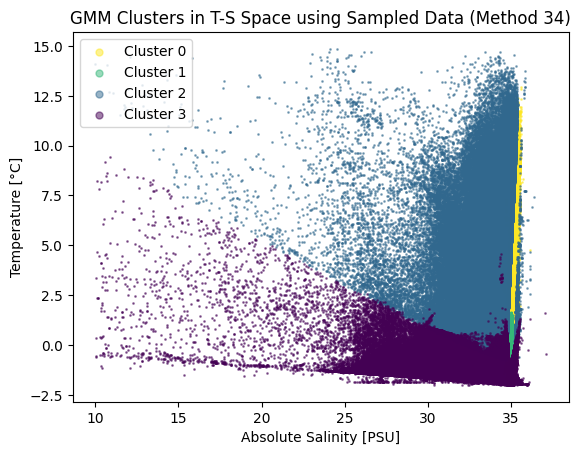

In [13]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [14]:
# Sample geographically for better plotting
df_sampled_plot = df_sampled.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters)

In [15]:
# Plot in 3D
plot_3d(n_clusters,df_sampled_plot)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TSDens_M34/funcs.py:625: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



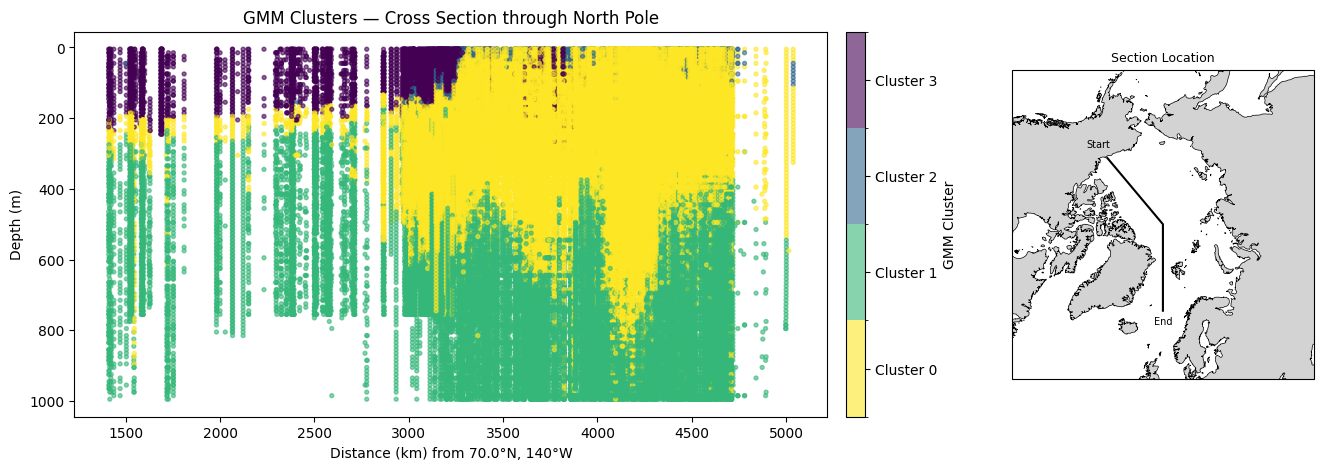

In [16]:
cross_sec_lon(df_sampled, n_clusters, -180, tol=0.5, start_lat=70.0, start_lon=-140)

In [17]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/TSDens_M34/funcs.py:717: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



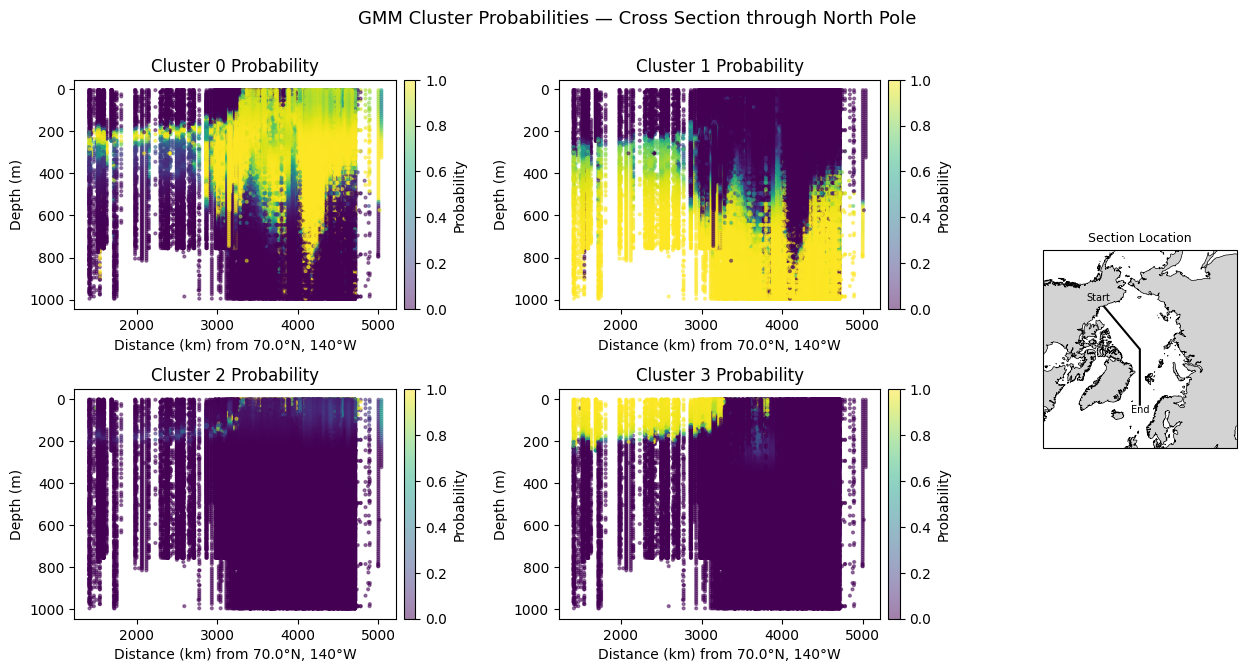

In [18]:
cross_sec_lon_prob(df_sampled, -180, tol=0.5, start_lat=70.0, start_lon=-140)